# 05 — Delivery-Partner Recommendation / Matching Engine

Frames dispatch as a recommendation problem: given a new order, rank the pool of available delivery partners by *predicted* performance (using the ETA model as a scoring function) blended with each partner's track-record reliability. Same ranking mechanics as a "recommend the best item" system — the object being ranked is a delivery partner, not a product.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
%matplotlib inline
pd.set_option('display.max_columns', 40)


In [2]:
import joblib, json
from recommendation import build_partner_profiles, recommend_partners

train = pd.read_parquet('../data/processed/train_clean.parquet')
profiles = build_partner_profiles(train)
profiles.to_csv('../models/partner_profiles.csv', index=False)
profiles.describe()

,avg_age,avg_rating,avg_vehicle_condition,n_deliveries,avg_time_taken,experience_score,reliability_score
count,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000
mean,29.627074,4.640499,1.023651,34.540152,26.347540,0.515525,0.804327
std,1.235868,0.068703,0.189624,21.305850,1.938133,0.317998,0.094987
min,24.583333,4.300000,0.333333,5.000000,19.444444,0.074627,0.637821
25%,28.901230,4.600000,0.910714,13.000000,25.211851,0.194030,0.706976
50%,29.585556,4.638549,1.018019,41.000000,26.278689,0.611940,0.835240
75%,30.286320,4.681434,1.130556,56.000000,27.461538,0.835821,0.899723
max,34.800000,4.853333,1.714286,67.000000,35.000000,1.000000,0.952149


## Partner reliability score

Blends historical rating (70%) with delivery-volume experience (30%), both normalized to 0-1.

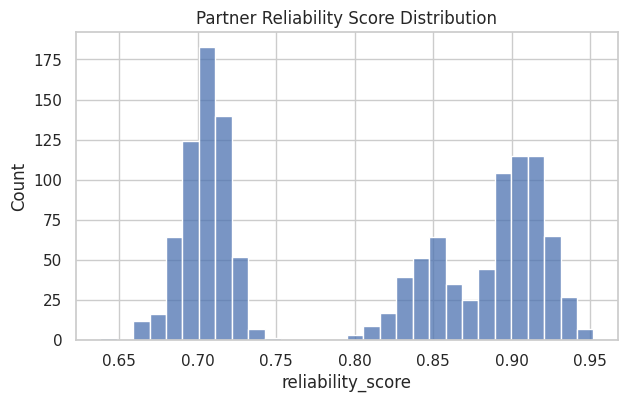

In [3]:
plt.figure(figsize=(7,4))
sns.histplot(profiles['reliability_score'], bins=30)
plt.title('Partner Reliability Score Distribution')
plt.show()

## Live recommendation demo

Simulating an incoming order and ranking 20 randomly-available candidate partners.

In [4]:
eta_model = joblib.load('../models/eta_model.pkl')
feature_columns = json.load(open('../models/eta_feature_columns.json'))

sample_order = {
    'distance_km': 8.5, 'order_hour': 19, 'order_dow': 4, 'is_weekend': 0,
    'is_rush_hour': 1, 'prep_time_min': 10, 'traffic_ordinal': 2,
    'distance_traffic_interaction': 17.0, 'bad_weather': 0, 'is_festival': 0,
    'multiple_deliveries': 1, 'Type_of_order': 'Snack', 'City': 'Metropolitian',
}
pool = profiles.sample(20, random_state=1)
top = recommend_partners(sample_order, pool, eta_model, feature_columns, top_k=5)
top[['Delivery_person_ID','avg_rating','n_deliveries','predicted_eta_min','reliability_score','dispatch_score']]

,Delivery_person_ID,avg_rating,n_deliveries,predicted_eta_min,reliability_score,dispatch_score
0,MUMRES02DEL01,4.586885,61,21.034302,0.915298,0.965296
1,CHENRES01DEL01,4.675926,54,21.267269,0.896421,0.939564
2,JAPRES17DEL02,4.654717,53,21.267269,0.888974,0.936586
3,SURRES09DEL03,4.697674,43,21.267269,0.850212,0.921081
4,VADRES04DEL03,4.631818,44,21.267269,0.845469,0.919184


## Result

The engine recommends partners balancing **speed** (60% weight, predicted ETA for this specific order) against **reliability** (40% weight, historical rating + experience) — a tunable trade-off a real dispatch team would set based on business priorities (e.g. weight speed higher during peak hours, reliability higher for high-value orders).